In [1]:
# paths
import numpy as np
import pandas as pd
from scipy import stats
import sys

sys.path.append('helpers/')
import helpers.pcca_fa.pcca_fa_mdl as pf
from dual_pfc_funcs import getParams, load_dict

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')
SAVE_FIG = True

# parameters
params = getParams()
subjects = params['subjects']
plot_sym = params['markers']
color_map = params['color_map']

In [2]:
data_path = 'preprocessed_data/'

pccafa = {}
for sub in subjects:
    pccafa = {**pccafa, **load_dict(data_path + sub + '_pccafa_cv15dim.pkl')}
fnames = pccafa.keys()

df = pd.DataFrame(columns=['SessionName','WxSv','WySv','LxSv','LySv','DSharedWx','DSharedWy','DSharedLx','DSharedLy'])
for i, (sess, curr_dat) in enumerate(pccafa.items()):
    mdl = pf.pcca_fa()
    mdl.set_params(curr_dat['params'])
    d_shared = mdl.compute_dshared()
    psv = mdl.compute_psv()
    
    df2 = {'SessionName':sess,'WxSv':psv['psv_x'],'WySv':psv['psv_y'],'LxSv':psv['psv_priv_x'],'LySv':psv['psv_priv_y'],'DSharedWx':d_shared['dshared_x'],'DSharedWy':d_shared['dshared_y'],'DSharedLx':d_shared['dshared_priv_x'],'DSharedLy':d_shared['dshared_priv_y']}
    df.loc[len(df)] = df2
# df

   SessionName       WxSv       WySv      LxSv      LySv
12    Pe180726  17.469354  14.965834  7.469525  5.653184


(None, None)

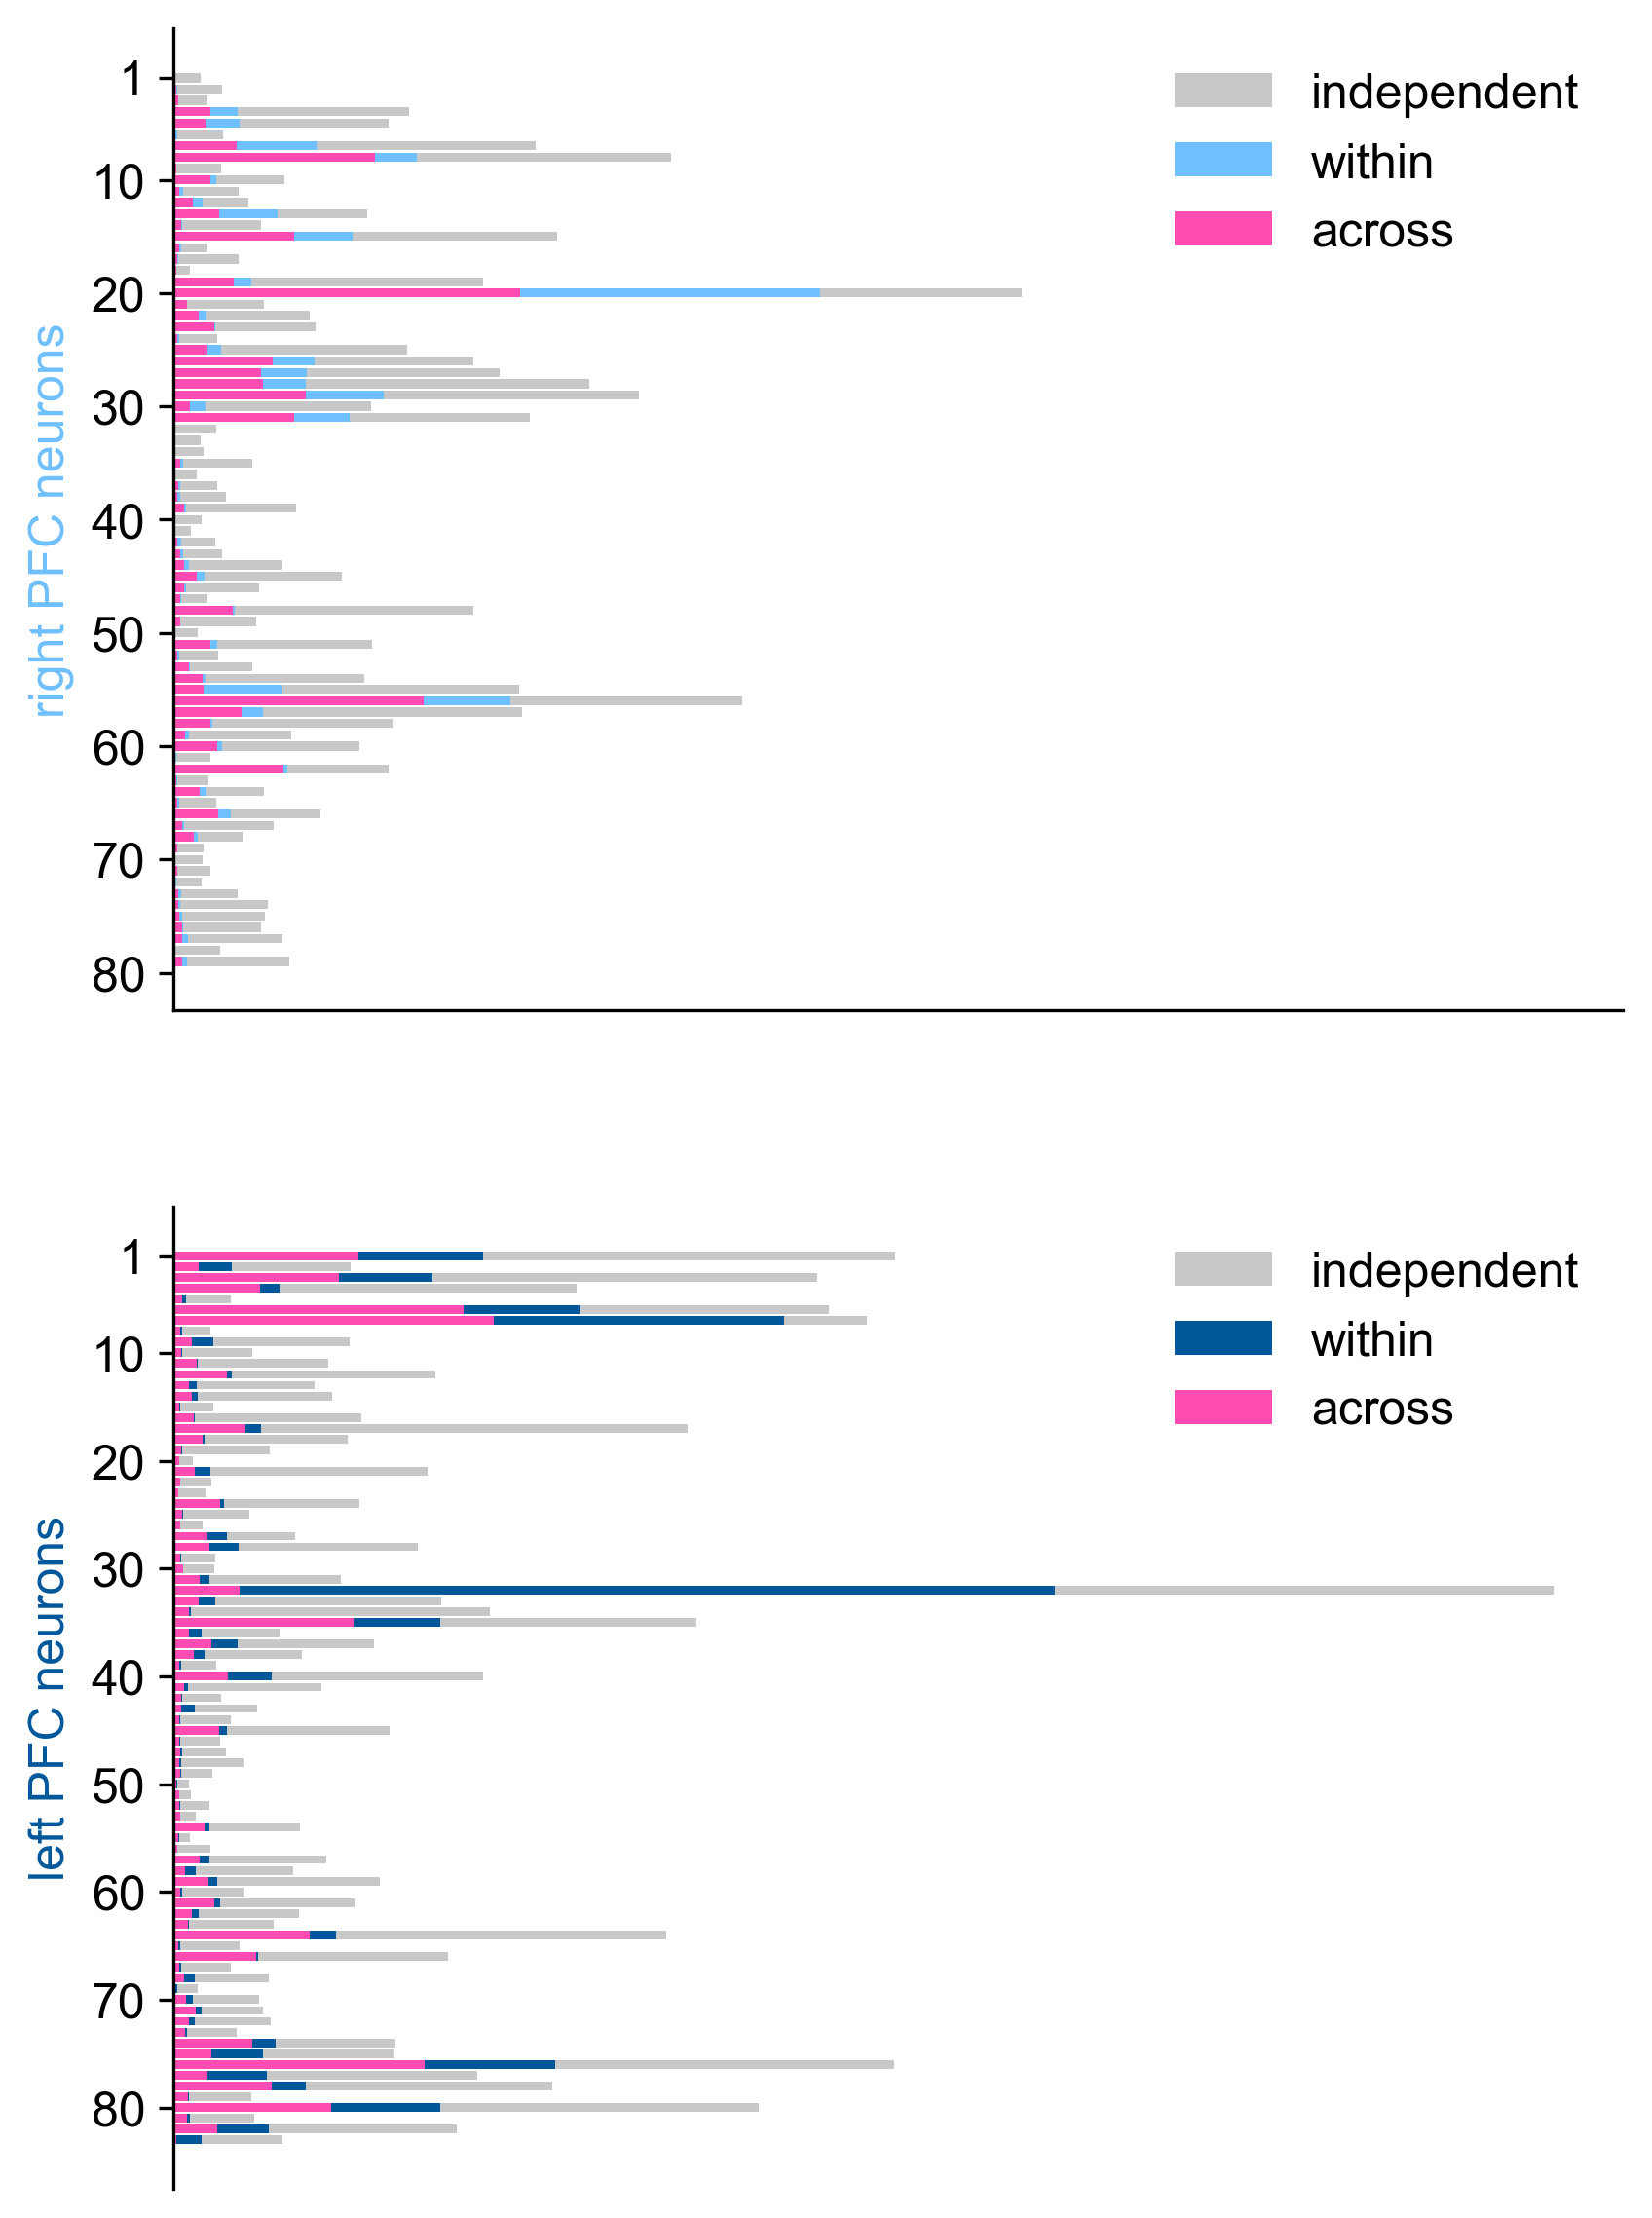

In [ ]:
# example session
ex_sess = 'Pe180726'
ex_idx = [s == ex_sess for s in df['SessionName']]
print(df[ex_idx][['SessionName','WxSv','WySv','LxSv','LySv']])

p = pccafa[ex_sess]['params']
mdl = pf.pcca_fa()
mdl.set_params(p)
wx,wy,lx,ly = mdl.get_loading_matrices()

across_x = np.diag(wx.dot(wx.T))
across_y = np.diag(wy.dot(wy.T))
within_x = np.diag(lx.dot(lx.T))
within_y = np.diag(ly.dot(ly.T))

total_x = across_x + within_x + p['psi_x'] # WWT + LLT + Psi
total_y = across_y + within_y + p['psi_y'] # WWT + LLT + Psi

nx = len(total_x) # xDim
ny = len(total_y) # yDim
zdim = p['zDim']
zxdim = p['zxDim']
zydim = p['zyDim']

# plot
fig,ax = plt.subplots(2,1,sharex=True)
fig.set_figheight(2*fig.get_figheight())

ax[1].barh(np.arange(1,nx+1,1),total_x,color=color_map['independent'],label='independent')
ax[1].barh(np.arange(1,nx+1,1),within_x+across_x,color=color_map['within2'],label='within')
ax[1].barh(np.arange(1,nx+1,1),across_x,color=color_map['across'],label='across')
ax[0].barh(np.arange(1,ny+1,1),total_y,color=color_map['independent'],label='independent')
ax[0].barh(np.arange(1,ny+1,1),within_y+across_y,color=color_map['within1'],label='within')
ax[0].barh(np.arange(1,ny+1,1),across_y,color=color_map['across'],label='across')

# plot formatting
ticks = np.arange(0,max([nx,ny]),10)
ticks[0] = 1
ax[0].invert_yaxis(),ax[1].invert_yaxis()
ax[0].set_yticks(ticks),ax[1].set_yticks(ticks)
ax[0].legend(loc='upper right',frameon=False),ax[1].legend(loc='upper right',frameon=False)
ax[1].set_xticks([])
ax[1].set_ylabel('left PFC neurons',color=color_map['within2'])
ax[0].set_ylabel('right PFC neurons',color=color_map['within1'])
ax[1].spines['bottom'].set_visible(False),ax[1].spines['bottom'].set_visible(False)

if SAVE_FIG:
    pdf = PdfPages('figs/partitions_ex_sess.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

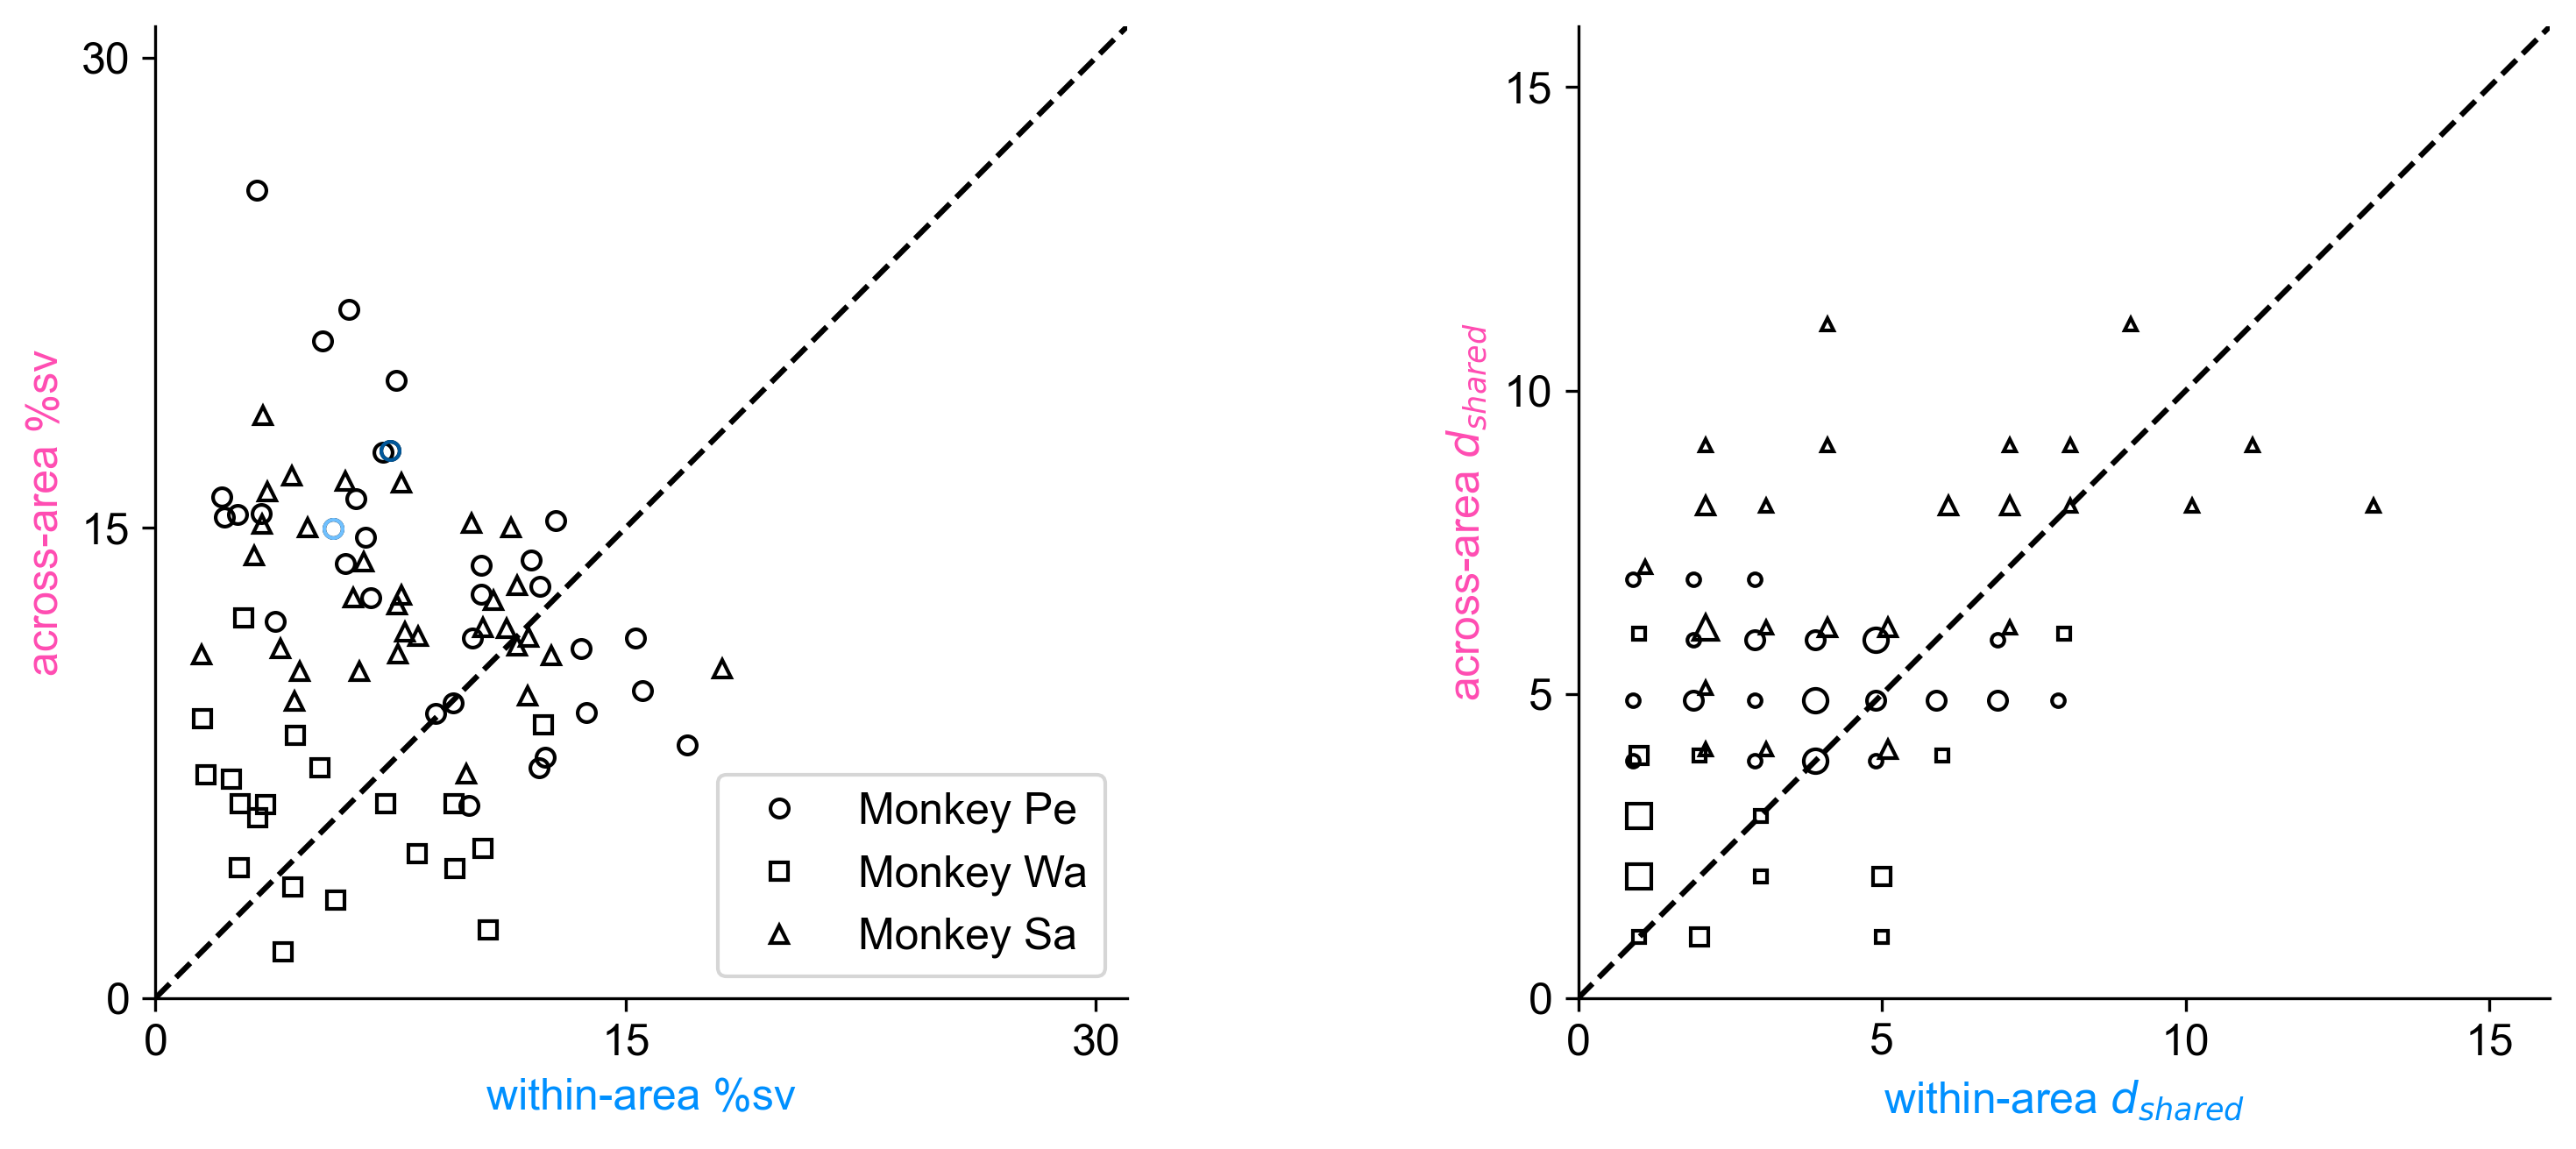

In [11]:
# create graphics 
fig,ax = plt.subplots(1,2)
fig.set_figwidth(2*fig.get_figwidth())

jitters = [-0.1,0,0.1]
for sub,sym,jit in zip(subjects,plot_sym,jitters):
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]

    psv_within = np.concatenate((tmp_df['LxSv'], tmp_df['LySv']))
    psv_across = np.concatenate((tmp_df['WxSv'], tmp_df['WySv']))
    ax[0].plot(psv_within,psv_across,marker=sym,ls='',color='k',label='Monkey {:s}'.format(sub_prefix),markersize=5,fillstyle='none')

    ds_within = np.concatenate((tmp_df['DSharedLx'], tmp_df['DSharedLy']))
    ds_across = np.concatenate((tmp_df['DSharedWx'], tmp_df['DSharedWy']))
    count_dict = dict()
    for tmp in zip(ds_within,ds_across):
        if tmp not in count_dict:
            count_dict[tmp] = 1
        else:
            count_dict[tmp] += 1
    for t in count_dict:
        ax[1].plot(t[0]+jit,t[1]+jit,marker=sym,ls='',color='k',markersize=2+1.5*count_dict[t],fillstyle='none')

# add example session coloring - pepe
ax[0].plot(df[ex_idx]['LxSv'],df[ex_idx]['WxSv'],marker='o',ls='',color=color_map['within2'],markersize=5,fillstyle='none')
ax[0].plot(df[ex_idx]['LySv'],df[ex_idx]['WySv'],marker='o',ls='',color=color_map['within1'],markersize=5,fillstyle='none')

# make plots pretty and display them
ax[0].plot([0,40],[0,40],'k--')
ax[1].plot([0,25],[0,25],'k--')

ax[0].set_xlabel('within-area %sv', color=color_map['within'])
ax[0].set_ylabel('across-area %sv', color=color_map['across'])
ax[1].set_xlabel('within-area $d_{shared}$', color=color_map['within'])
ax[1].set_ylabel('across-area $d_{shared}$', color=color_map['across'])

ax[0].set_xlim([0,31])
ax[0].set_ylim([0,31])
ax[0].set_xticks(np.arange(0,31,15))
ax[0].set_yticks(np.arange(0,31,15))

ax[1].set_xlim([0,16])
ax[1].set_ylim([0,16])
ax[1].set_xticks(np.arange(0,16,5))
ax[1].set_yticks(np.arange(0,16,5))

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].legend(loc='lower right')

if SAVE_FIG:
    pdf = PdfPages('figs/across_vs_within.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [12]:
# statistics
alpha = 0.01

# test if across and within are different across all monkeys
psv_within = np.concatenate((df['LxSv'], df['LySv']))
psv_across = np.concatenate((df['WxSv'], df['WySv']))

ds_within = np.concatenate((df['DSharedLx'], df['DSharedLy']))
ds_across = np.concatenate((df['DSharedWx'], df['DSharedWy']))

print('dim: across={:.3f} +/- {:.3f} s.e.m., within={:.3f} +/- {:.3f} s.e.m.'.format(np.mean(ds_across),stats.sem(ds_across),np.mean(ds_within),stats.sem(ds_within)))
print('psv: across={:.3f} +/- {:.3f} s.e.m., within={:.3f} +/- {:.3f} s.e.m.'.format(np.mean(psv_across),stats.sem(psv_across),psv_within.mean(),stats.sem(psv_within)))

_,pdim = stats.ttest_rel(ds_across,ds_within,alternative='greater')
_,ppsv = stats.ttest_rel(psv_across,psv_within,alternative='greater')
print()
print('Across greater than within?')
print('Pooled, dim: {}, p = {:5f}'.format(pdim<alpha,pdim))
print('Pooled, psv: {}, p = {:5f}'.format(ppsv<alpha,ppsv))
print()
for sub in subjects:
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]

    psv_within = np.concatenate((tmp_df['LxSv'], tmp_df['LySv']))
    psv_across = np.concatenate((tmp_df['WxSv'], tmp_df['WySv']))

    ds_within = np.concatenate((tmp_df['DSharedLx'], tmp_df['DSharedLy']))
    ds_across = np.concatenate((tmp_df['DSharedWx'], tmp_df['DSharedWy']))

    # test if across and within are different for this monkey
    _,pdim = stats.ttest_rel(ds_across,ds_within,alternative='greater')
    _,ppsv = stats.ttest_rel(psv_across,psv_within,alternative='greater')
    print('Monkey {:s}, dim: {}, p = {:5f}'.format(sub_prefix,pdim<alpha,pdim))
    print('Monkey {:s}, psv: {}, p = {:5f}'.format(sub_prefix,ppsv<alpha,ppsv))

dim: across=5.405 +/- 0.243 s.e.m., within=4.060 +/- 0.280 s.e.m.
psv: across=11.495 +/- 0.505 s.e.m., within=7.659 +/- 0.432 s.e.m.

Across greater than within?
Pooled, dim: True, p = 0.000003
Pooled, psv: True, p = 0.000000

Monkey Pe, dim: True, p = 0.001281
Monkey Pe, psv: True, p = 0.000476
Monkey Wa, dim: False, p = 0.320484
Monkey Wa, psv: False, p = 0.399499
Monkey Sa, dim: True, p = 0.000090
Monkey Sa, psv: True, p = 0.000004


%sv diff -  -3.8356829941648205
d-shared diff -  -1.3452380952380953


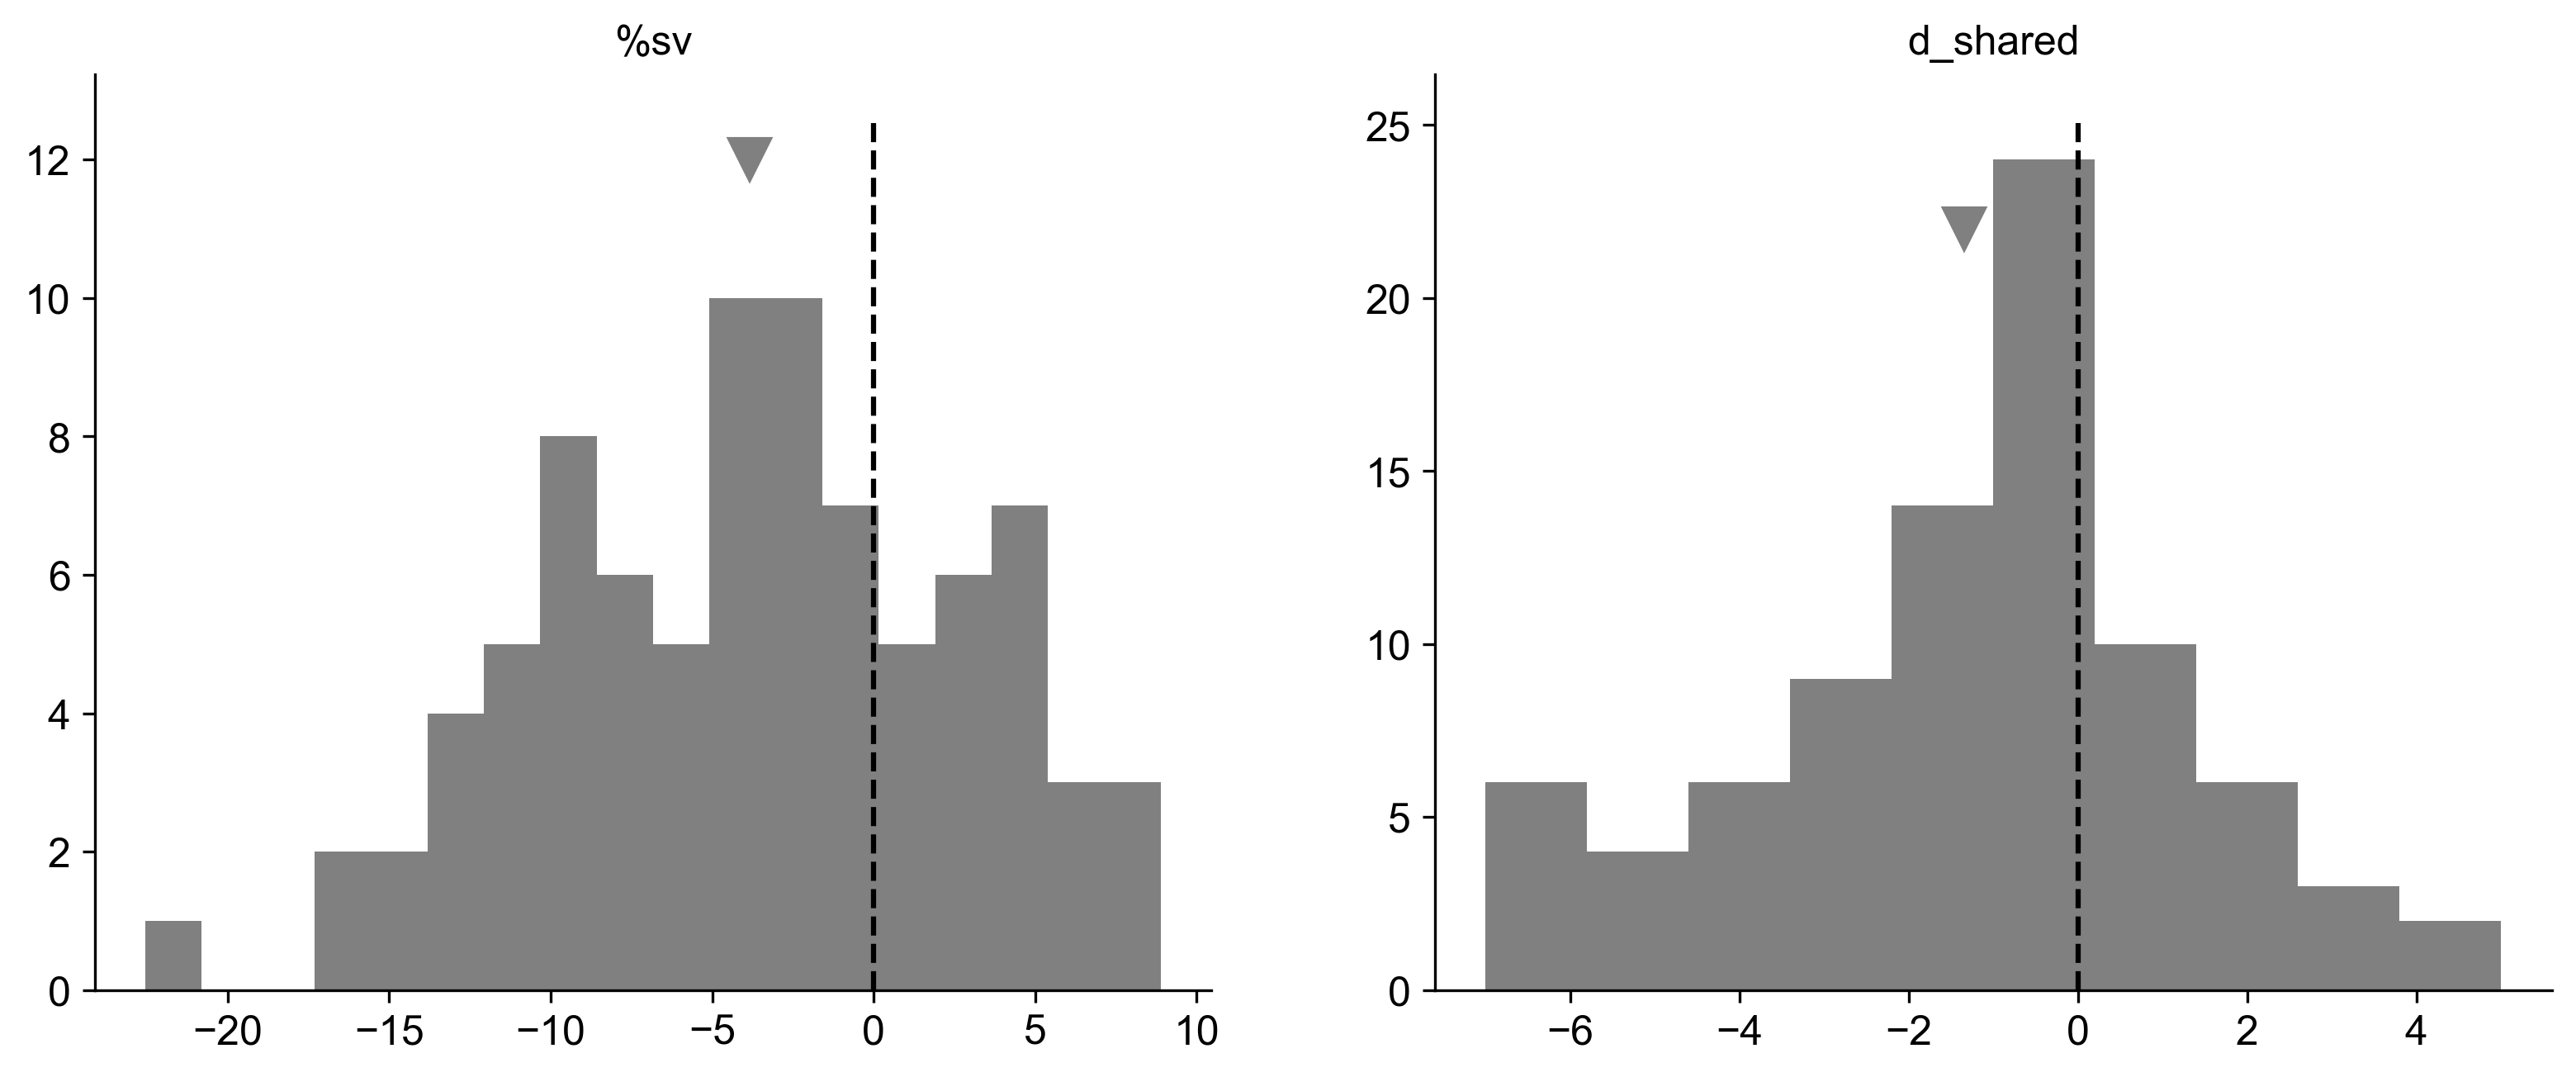

In [13]:
# difference histogram plot - insets
psv_within = np.concatenate((df['LxSv'], df['LySv']))
psv_across = np.concatenate((df['WxSv'], df['WySv']))

ds_within = np.concatenate((df['DSharedLx'], df['DSharedLy']))
ds_across = np.concatenate((df['DSharedWx'], df['DSharedWy']))

d_diff = ds_within - ds_across
psv_diff = psv_within - psv_across

fig,ax = plt.subplots(1,2)
fig.set_figwidth(2*fig.get_figwidth())

tmp = ax[1].plot(d_diff.mean(),22,marker='v',color=[.5,.5,.5],ms=12)
ax[1].hist(d_diff,bins=10,color=tmp[0].get_color())
ax[1].plot([0,0],ax[1].get_ylim(),'k--')
ax[1].set_title('d_shared')

tmp = ax[0].plot(psv_diff.mean(),12,marker='v',color=[.5,.5,.5],ms=12)
ax[0].hist(psv_diff,bins=18,color=tmp[0].get_color())
ax[0].plot([0,0],ax[0].get_ylim(),'k--')
ax[0].set_title('%sv')

print('%sv diff - ', psv_diff.mean())
print('d-shared diff - ', d_diff.mean())

if SAVE_FIG:
    pdf = PdfPages('figs/across_vs_within_diffs.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()